# Módulo 2 — Análise de Agrupamentos (Clustering)

### Notebook prático da aula de 60 minutos

**Executa integralmente no Google Colab, sem instalar bibliotecas e sem utilizar chaves de API.**

Todos os dados são gerados sinteticamente com uma semente fixa. Assim, todos visualizam exatamente os mesmos dados, resultados e gráficos.

| Bloco | Conteúdo                                                                 | Seção |
| :---: | ------------------------------------------------------------------------ | :---: |
|   1   | Por que a escala das variáveis faz parte do modelo                       |   §1  |
|   2   | K-Means: o algoritmo, iteração por iteração                              |   §2  |
|   3   | Escolhendo K: método do cotovelo, silhueta e estabilidade                |   §3  |
|   4   | Clustering hierárquico e dendrograma                                     |   §4  |
|   5   | DBSCAN: densidade, ruído e formas arbitrárias                            |   §5  |
|   6   | Comparação dos três algoritmos em quatro geometrias diferentes           |   §6  |
|   7   | Avaliação: silhueta por cluster, Davies–Bouldin, Calinski–Harabasz e ARI |   §7  |
|   8   | Armadilhas do clustering, incluindo agrupamento em ruído puro            |   §8  |
|   9   | Caso aplicado: segmentação RFM de ponta a ponta                          |   §9  |
|   10  | Estado da arte executável: HDBSCAN e clustering de textos                |  §10  |

> **Como usar em aula:** cada seção é independente. Execute primeiro a seção `Ambiente` e, depois, avance diretamente para a seção que deseja demonstrar.


## Ambiente

In [ ]:
# Nenhuma instalação é necessária: tudo já vem no Colab.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.cluster import KMeans, MiniBatchKMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score,
                             adjusted_rand_score)
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

SEED = 42
rng = np.random.default_rng(SEED)
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})
PALETA = ["#0B7285", "#D9480F", "#5F3DC4", "#2B8A3E", "#B08A2E", "#9C36B5"]
def cores(labels):
    "Mapeia rótulos para cores; ruído (-1) fica cinza."
    return np.array(["#B8C4CE" if l == -1 else PALETA[int(l) % len(PALETA)] for l in labels])

print("Ambiente pronto. numpy", np.__version__, "| pandas", pd.__version__)

Ambiente pronto. numpy 2.0.2 | pandas 2.2.3


---

## §1 — A escala das variáveis faz parte do modelo

O **K-Means** utiliza distâncias para formar os agrupamentos. Quando uma variável varia de **0 a 100.000** e outra de **0 a 100**, a variável com maior escala domina o cálculo da distância e, consequentemente, pode determinar o agrupamento praticamente sozinha.

Vamos observar esse efeito inicialmente com dois clientes e, em seguida, com um conjunto completo de dados.


In [ ]:
# Dois clientes, duas variáveis em escalas muito diferentes
A = np.array([25, 4000.0])
# idade, renda
B = np.array([60, 4500.0])
d_bruta = np.linalg.norm(A - B)
print(f"Distância sem padronizar : {d_bruta:.2f}")
print(f"  contribuição da idade  : {abs(A[0]-B[0])**2 / ((A-B)**2).sum():.1%}")
print(f"  contribuição da renda  : {abs(A[1]-B[1])**2 / ((A-B)**2).sum():.1%}")
print("\n35 anos de diferença viram um detalhe irrelevante diante de R$ 500.")

Distância sem padronizar : 501.22
  contribuição da idade  : 0.5%
  contribuição da renda  : 99.5%

35 anos de diferença viram um detalhe irrelevante diante de R$ 500.


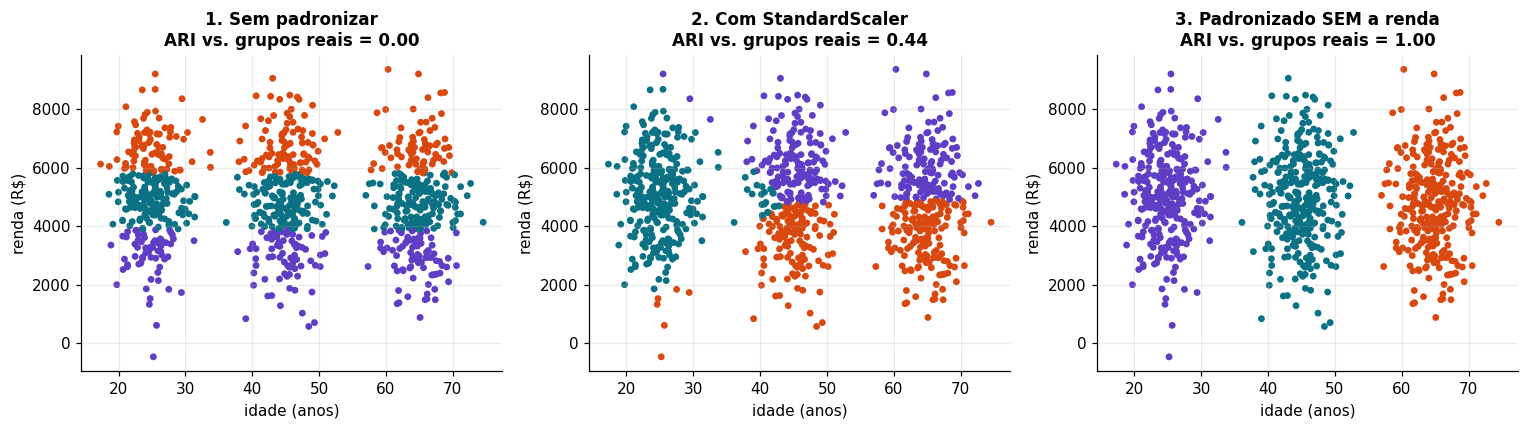

1) Sem padronizar: o K-Means corta em faixas HORIZONTAIS — a renda (que é ruído) decide tudo.
2) Padronizar ajuda, mas NÃO resolve: a renda continua com peso igual mesmo sem informação,
   e os grupos ficam alongados, o que o K-Means detesta — por isso ele ainda os fatia.
3) Padronizar + REMOVER a variável sem informação: recuperação perfeita.

Lição honesta: escalar é necessário, mas não é suficiente. Seleção de variáveis também é modelagem.


In [ ]:
# Três grupos claros em 'idade'; 'renda' é ruído puro, em escala 100x maior
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

SEED = 42
rng = np.random.default_rng(SEED)
PALETA = ["#0B7285", "#D9480F", "#5F3DC4", "#2B8A3E", "#B08A2E", "#9C36B5"]
def cores(labels):
    "Mapeia rótulos para cores; ruído (-1) fica cinza."
    return np.array(["#B8C4CE" if l == -1 else PALETA[int(l) % len(PALETA)] for l in labels])

n = 300
idade  = np.concatenate([rng.normal(25, 3, n), rng.normal(45, 3, n), rng.normal(65, 3, n)])
renda  = rng.normal(5000, 1500, 3 * n)          # nenhuma estrutura aqui
y_real = np.repeat([0, 1, 2], n)
X = np.c_[idade, renda]
cenarios = {
    "1. Sem padronizar":            (X, np.c_[idade, renda]),
    "2. Com StandardScaler":        (StandardScaler().fit_transform(X), np.c_[idade, renda]),
    "3. Padronizado SEM a renda":   (StandardScaler().fit_transform(idade.reshape(-1, 1)),
                                     np.c_[idade, renda]),
}
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for a, (tit, (Xin, Xplot)) in zip(ax, cenarios.items()):
    lab = KMeans(3, n_init=10, random_state=SEED).fit_predict(Xin)
    a.scatter(Xplot[:, 0], Xplot[:, 1], c=cores(lab), s=12)
    a.set_xlabel("idade (anos)"); a.set_ylabel("renda (R$)")
    a.set_title(f"{tit}\nARI vs. grupos reais = {adjusted_rand_score(y_real, lab):.2f}")
plt.tight_layout(); plt.show()
print("1) Sem padronizar: o K-Means corta em faixas HORIZONTAIS — a renda (que é ruído) decide tudo.")
print("2) Padronizar ajuda, mas NÃO resolve: a renda continua com peso igual mesmo sem informação,")
print("   e os grupos ficam alongados, o que o K-Means detesta — por isso ele ainda os fatia.")
print("3) Padronizar + REMOVER a variável sem informação: recuperação perfeita.")
print("\nLição honesta: escalar é necessário, mas não é suficiente. Seleção de variáveis também é modelagem.")

In [ ]:
base = np.r_[rng.normal(50, 10, 200), [250.0]]
# 200 valores normais + 1
outliertab = pd.DataFrame({
    "original":       base,
    "StandardScaler": StandardScaler().fit_transform(base.reshape(-1, 1)).ravel(),
    "MinMaxScaler":   MinMaxScaler().fit_transform(base.reshape(-1, 1)).ravel(),
    "RobustScaler":   RobustScaler().fit_transform(base.reshape(-1, 1)).ravel(),
})
print(outliertab.describe().loc[["mean", "std", "min", "max"]].round(2))
print("\nMinMax comprime tudo para perto de 0 por causa de UM outlier.")
print("RobustScaler usa mediana e IQR, então quase não se abala.")

      original  StandardScaler  MinMaxScaler  RobustScaler
mean     51.04           -0.00          0.12          0.03
std      17.00            1.00          0.08          1.36
min      23.98           -1.60          0.00         -2.13
max     250.00           11.73          1.00         15.96

MinMax comprime tudo para perto de 0 por causa de UM outlier.
RobustScaler usa mediana e IQR, então quase não se abala.


---

## §2 — K-Means: iteração por iteração

Nesta seção, o algoritmo será implementado manualmente em aproximadamente **15 linhas de código**, permitindo visualizar claramente cada etapa do processo.

O funcionamento segue exatamente a analogia dos **food trucks**:

1. **Atribuir:** cada cliente é associado ao food truck mais próximo.
2. **Recalcular:** cada food truck é reposicionado no centro médio dos clientes atribuídos a ele.
3. **Repetir:** as etapas anteriores são executadas novamente até que os food trucks não mudem mais de posição.


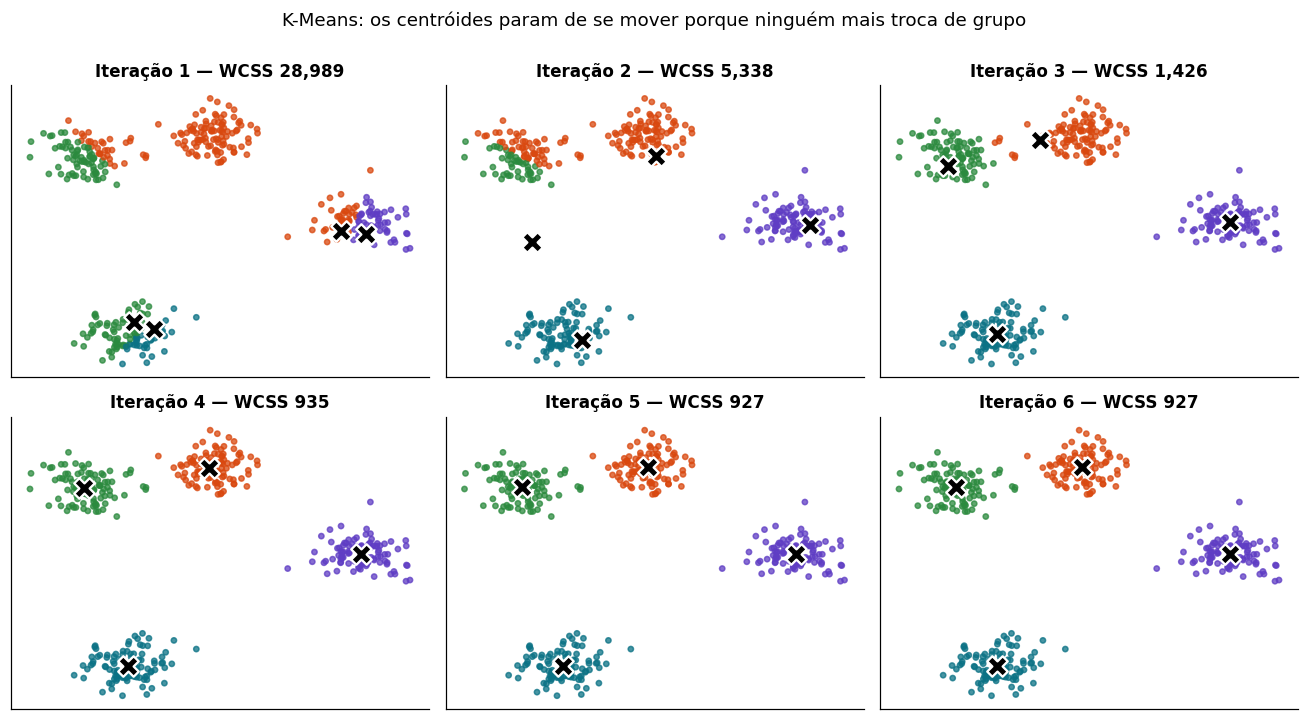

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

SEED = 42
rng = np.random.default_rng(SEED)
PALETA = ["#0B7285", "#D9480F", "#5F3DC4", "#2B8A3E", "#B08A2E", "#9C36B5"]
def cores(labels):
    "Mapeia rótulos para cores; ruído (-1) fica cinza."
    return np.array(["#B8C4CE" if l == -1 else PALETA[int(l) % len(PALETA)] for l in labels])

X2, y2 = make_blobs(n_samples=400, centers=4, cluster_std=1.1, random_state=SEED)
def kmeans_passos(X, k, n_iter=6, seed=7):
    "K-Means didático: devolve o histórico de centróides e rótulos a cada iteração."
    r = np.random.default_rng(seed)
    C = X[r.choice(len(X), k, replace=False)]        # inicialização aleatória (de propósito)
    hist = []
    for _ in range(n_iter):
        d = ((X[:, None, :] - C[None, :, :]) ** 2).sum(-1)   # distâncias ao quadrado
        lab = d.argmin(1)                                     # 1) atribuir
        hist.append((C.copy(), lab.copy()))
        C = np.array([X[lab == j].mean(0) if (lab == j).any() else C[j] for j in range(k)])  # 2) atualizar
    return hist
hist = kmeans_passos(X2, k=4)
fig, ax = plt.subplots(2, 3, figsize=(12, 6.5))
for i, (C, lab) in enumerate(hist):
    a = ax.ravel()[i]
    a.scatter(X2[:, 0], X2[:, 1], c=cores(lab), s=12, alpha=.75)
    a.scatter(C[:, 0], C[:, 1], c="black", s=180, marker="X", edgecolor="white", linewidth=1.5)
    wcss = sum(((X2[lab == j] - C[j]) ** 2).sum() for j in range(4))
    a.set_title(f"Iteração {i+1} — WCSS {wcss:,.0f}")
    a.set_xticks([]); a.set_yticks([])
plt.suptitle("K-Means: os centróides param de se mover porque ninguém mais troca de grupo", y=1.0)
plt.tight_layout(); plt.show()

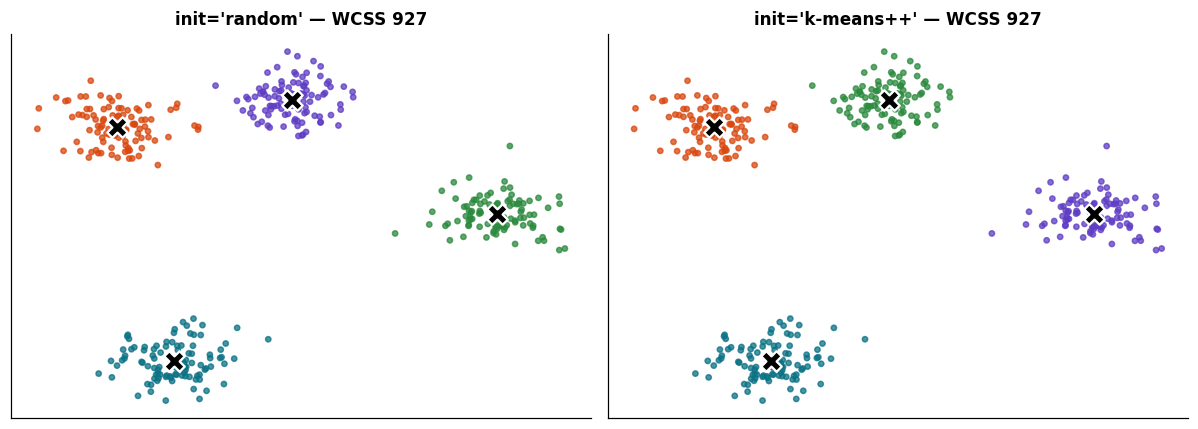

random     -> WCSS médio 1,752 | pior caso 11,608
k-means++  -> WCSS médio 927 | pior caso 927

Convergir não é achar o ótimo: o algoritmo para em um mínimo LOCAL.


In [ ]:
# Inicialização importa: 'random' vs 'k-means++' com uma única semente cada (n_init=1)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, init in zip(ax, ["random", "k-means++"]):
    km = KMeans(4, init=init, n_init=1, random_state=3).fit(X2)
    a.scatter(X2[:, 0], X2[:, 1], c=cores(km.labels_), s=12, alpha=.75)
    a.scatter(*km.cluster_centers_.T, c="black", s=180, marker="X", edgecolor="white", linewidth=1.5)
    a.set_title(f"init='{init}' — WCSS {km.inertia_:,.0f}")
    a.set_xticks([]); a.set_yticks([])
plt.tight_layout()
plt.show()

# Distribuição do WCSS final em 50 sementes diferentes
w_rand = [KMeans(4, init="random",    n_init=1, random_state=s).fit(X2).inertia_ for s in range(50)]
w_pp   = [KMeans(4, init="k-means++", n_init=1, random_state=s).fit(X2).inertia_ for s in range(50)]
print(f"random     -> WCSS médio {np.mean(w_rand):,.0f} | pior caso {np.max(w_rand):,.0f}")
print(f"k-means++  -> WCSS médio {np.mean(w_pp):,.0f} | pior caso {np.max(w_pp):,.0f}")
print("\nConvergir não é achar o ótimo: o algoritmo para em um mínimo LOCAL.")

---

## §3 — Escolhendo K: cotovelo, silhueta e estabilidade

Nesta seção, analisaremos **três perspectivas complementares** para escolher o número de clusters (**K**). As duas primeiras correspondem aos métodos clássicos, enquanto a terceira adiciona uma avaliação de robustez essencial em aplicações profissionais:

1. **Método do cotovelo:** avalia a redução da variabilidade interna dos clusters à medida que K aumenta.
2. **Coeficiente de silhueta:** mede simultaneamente a coesão dentro dos clusters e a separação entre eles.
3. **Análise de estabilidade:** verifica se os agrupamentos permanecem consistentes diante de diferentes amostras, inicializações ou pequenas alterações nos dados.

> **Ideia central:** um valor de K não deve apenas produzir boas métricas; ele também deve gerar agrupamentos estáveis, interpretáveis e úteis para o objetivo da análise.


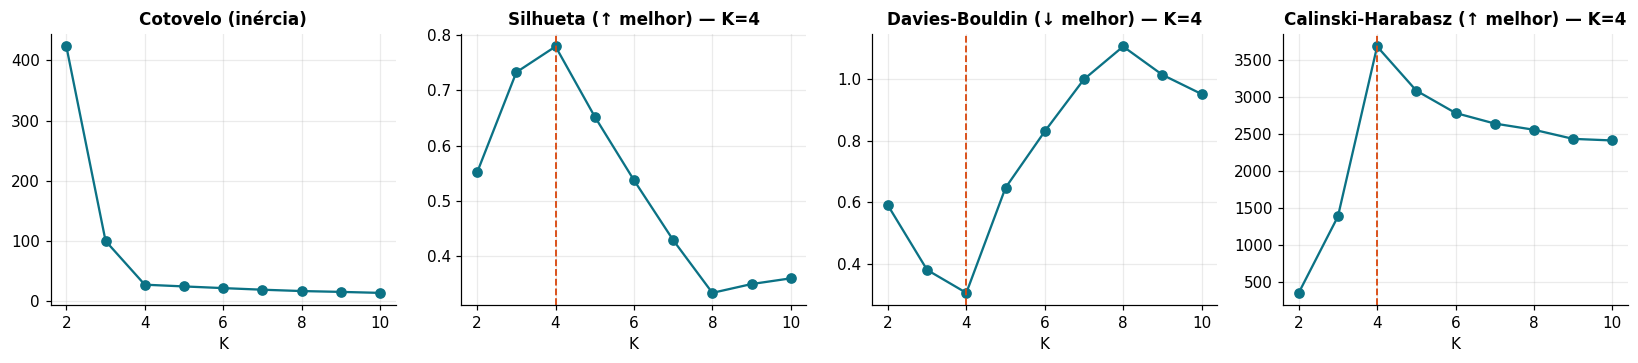

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

SEED = 42
PALETA = ["#0B7285", "#D9480F", "#5F3DC4", "#2B8A3E", "#B08A2E", "#9C36B5"]

Xs = StandardScaler().fit_transform(X2)
Ks = range(2, 11)
inercia, sil, db, ch = [], [], [], []
for k in Ks:
    lab = KMeans(k, n_init=10, random_state=SEED).fit(Xs)
    inercia.append(lab.inertia_)
    sil.append(silhouette_score(Xs, lab.labels_))
    db.append(davies_bouldin_score(Xs, lab.labels_))
    ch.append(calinski_harabasz_score(Xs, lab.labels_))
fig, ax = plt.subplots(1, 4, figsize=(15, 3.4))
for a, v, t, melhor in zip(ax, [inercia, sil, db, ch],
                           ["Cotovelo (inércia)", "Silhueta (↑ melhor)",
                            "Davies-Bouldin (↓ melhor)", "Calinski-Harabasz (↑ melhor)"],
                           [None, np.argmax, np.argmin, np.argmax]):
    a.plot(list(Ks), v, "o-", color=PALETA[0])
    if melhor is not None:
        k_ot = list(Ks)[melhor(v)]
        a.axvline(k_ot, color=PALETA[1], ls="--", lw=1.2)
        a.set_title(f"{t} — K={k_ot}")
    else:
        a.set_title(t)
    a.set_xlabel("K")
plt.tight_layout(); plt.show()

In [ ]:
# Estabilidade: o K escolhido sobrevive à reamostragem?
def estabilidade(X, k, n_rep=30, frac=0.8, seed=SEED):
    "Reamostra, reagrupa e mede a concordância (ARI) com o agrupamento de referência."
    r = np.random.default_rng(seed)
    ref = KMeans(k, n_init=10, random_state=seed).fit(X)
    scores = []
    for _ in range(n_rep):
        idx = r.choice(len(X), int(frac * len(X)), replace=False)
        lab = KMeans(k, n_init=10, random_state=int(r.integers(1e6))).fit_predict(X[idx])
        scores.append(adjusted_rand_score(ref.labels_[idx], lab))
    return np.mean(scores), np.std(scores)

print(f"{'K':>3} {'ARI médio':>11} {'desvio':>9}   leitura")
for k in range(2, 8):
    m, s = estabilidade(Xs, k)
    marca = "estável" if m > 0.85 else ("instável" if m < 0.7 else "razoável")
    print(f"{k:>3} {m:>11.3f} {s:>9.3f}   {marca}")
print("\nUm K com ARI baixo sob reamostragem não sustenta uma decisão de negócio.")

  K   ARI médio    desvio   leitura
  2       0.975     0.134   estável
  3       1.000     0.000   estável
  4       1.000     0.000   estável
  5       0.882     0.087   estável
  6       0.855     0.090   estável
  7       0.835     0.112   razoável

Um K com ARI baixo sob reamostragem não sustenta uma decisão de negócio.


---

## §4 — Clustering hierárquico e dendrograma

O **dendrograma** representa visualmente todo o processo de formação dos agrupamentos. Em vez de definir previamente um único valor de **K**, é possível explorar diferentes quantidades de clusters escolhendo a altura em que o dendrograma será cortado.

Nesta seção, também compararemos os quatro principais critérios de ligação (*linkage*) utilizando o mesmo conjunto de dados:

1. **Single linkage:** considera a menor distância entre elementos de clusters diferentes.
2. **Complete linkage:** considera a maior distância entre elementos de clusters diferentes.
3. **Average linkage:** utiliza a distância média entre os elementos dos clusters.
4. **Ward linkage:** busca minimizar o aumento da variância interna após cada união.

> **Ideia central:** a altura do corte determina o número de clusters, enquanto o critério de ligação influencia diretamente o formato e a organização dos agrupamentos.


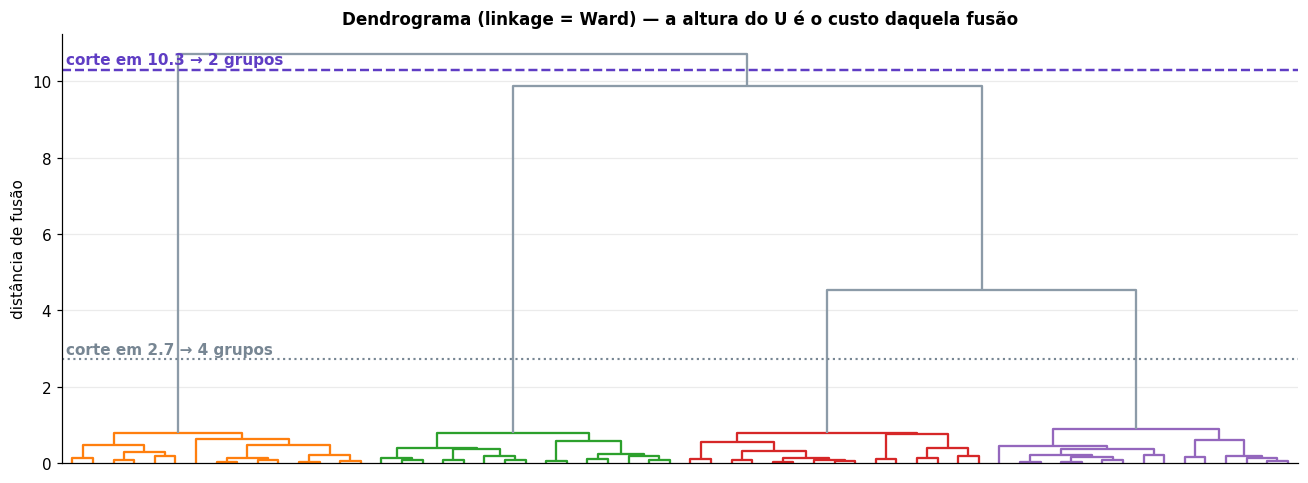

O MESMO modelo entrega qualquer K — você só muda a altura do corte:

  corte em 10.31  ->  2 grupos
  corte em  7.22  ->  3 grupos
  corte em  2.71  ->  4 grupos
  corte em  0.79  ->  6 grupos


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

SEED = 42
PALETA = ["#0B7285", "#D9480F", "#5F3DC4", "#2B8A3E", "#B08A2E", "#9C36B5"]

X4, _ = make_blobs(n_samples=60, centers=4, cluster_std=1.0, random_state=SEED)
X4s = StandardScaler().fit_transform(X4)
Z = linkage(X4s, method="ward")
# A altura que produz exatamente k grupos fica entre as duas últimas fusões relevantes
def altura_para_k(Z, k):
    return (Z[-k, 2] + Z[-(k - 1), 2]) / 2
h2, h4 = altura_para_k(Z, 2), altura_para_k(Z, 4)
fig, ax = plt.subplots(figsize=(12, 4.5))
dendrogram(Z, ax=ax, color_threshold=h4, above_threshold_color="#8C9BA8", no_labels=True)
ax.axhline(h2, color=PALETA[2], ls="--", lw=1.6)
ax.text(2, h2 + .15, f"corte em {h2:.1f} → 2 grupos", color=PALETA[2], fontweight="bold")
ax.axhline(h4, color="#778693", ls=":", lw=1.4)
ax.text(2, h4 + .15, f"corte em {h4:.1f} → 4 grupos", color="#778693", fontweight="bold")
ax.set_title("Dendrograma (linkage = Ward) — a altura do U é o custo daquela fusão")
ax.set_ylabel("distância de fusão")
plt.tight_layout(); plt.show()
print("O MESMO modelo entrega qualquer K — você só muda a altura do corte:\n")
for k in [2, 3, 4, 6]:
    h = altura_para_k(Z, k)
    obtido = len(np.unique(fcluster(Z, h, criterion="distance")))
    print(f"  corte em {h:>5.2f}  ->  {obtido} grupos")

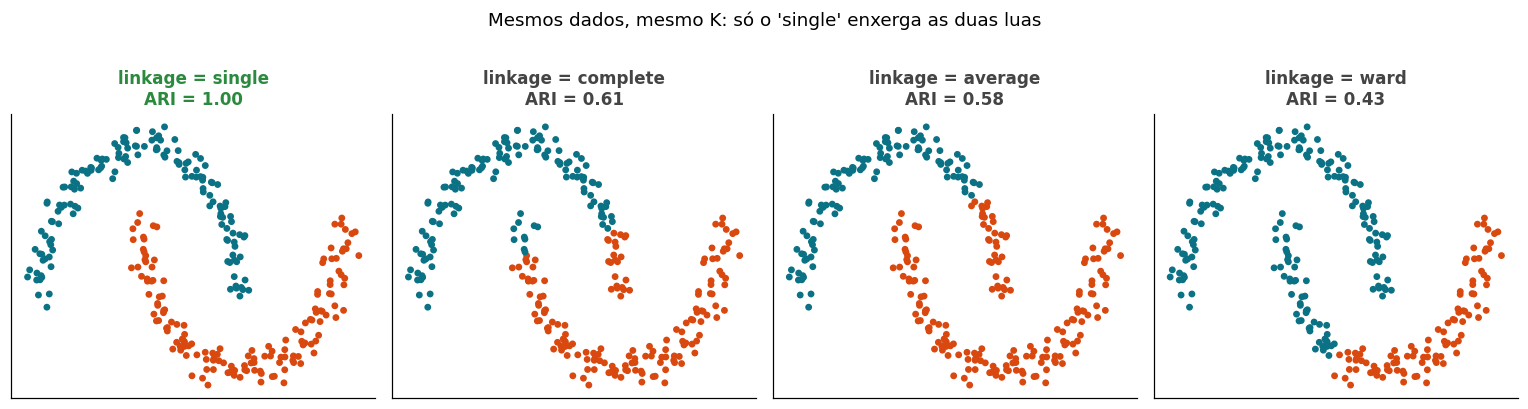

Olhando rápido as quatro figuras parecem iguais — o ARI mostra que não são.
Single conecta por proximidade mínima, então segue curvas. Mas é por esse mesmo
motivo que ele funde grupos ligados por uma trilha fina de pontos (efeito cadeia).


In [ ]:
# O linkage muda o modelo — repare no efeito cadeia do 'single' nas luas
X_luas, y_luas = make_moons(n_samples=300, noise=0.06, random_state=SEED)
X_luas = StandardScaler().fit_transform(X_luas)
fig, ax = plt.subplots(1, 4, figsize=(14, 3.6))
for a, m in zip(ax, ["single", "complete", "average", "ward"]):
    lab = AgglomerativeClustering(n_clusters=2, linkage=m).fit_predict(X_luas)
    ari = adjusted_rand_score(y_luas, lab)
    a.scatter(X_luas[:, 0], X_luas[:, 1], c=cores(lab), s=12)
    a.set_title(f"linkage = {m}\nARI = {ari:.2f}", color=(PALETA[3] if ari > .9 else "#444"))
    a.set_xticks([]); a.set_yticks([])
plt.suptitle("Mesmos dados, mesmo K: só o 'single' enxerga as duas luas", y=1.02)
plt.tight_layout()
plt.show()
print("Olhando rápido as quatro figuras parecem iguais — o ARI mostra que não são.")
print("Single conecta por proximidade mínima, então segue curvas. Mas é por esse mesmo")
print("motivo que ele funde grupos ligados por uma trilha fina de pontos (efeito cadeia).")

In [ ]:
# O custo de memória do hierárquico, em números
for n in [1_000, 10_000, 100_000, 1_000_000]:
    gb = n * n / 2 * 8 / 1024**3
    print(f"n = {n:>9,}  ->  matriz de distâncias ≈ {gb:>10,.2f} GB")
print("\nÉ por isso que o hierárquico não escala: o gargalo é RAM, não CPU.")

n =     1,000  ->  matriz de distâncias ≈       0.00 GB
n =    10,000  ->  matriz de distâncias ≈       0.37 GB
n =   100,000  ->  matriz de distâncias ≈      37.25 GB
n = 1,000,000  ->  matriz de distâncias ≈   3,725.29 GB

É por isso que o hierárquico não escala: o gargalo é RAM, não CPU.


---

## §5 — DBSCAN: densidade, ruído e formas arbitrárias

O **DBSCAN** identifica agrupamentos com base na densidade dos dados e consegue encontrar clusters com formatos arbitrários, além de detectar observações consideradas ruído. Diferentemente do K-Means, ele não exige a definição prévia do número de clusters (**K**).

O algoritmo utiliza dois parâmetros principais:

* `eps`: define o raio máximo da vizinhança de cada ponto;
* `min_samples`: determina a quantidade mínima de pontos necessária para formar uma região densa.

Nesta seção, escolheremos um valor adequado para `eps` por meio do **gráfico de k-distâncias** (*k-distance graph*). Em seguida, visualizaremos os três tipos de pontos identificados pelo DBSCAN:

* **Pontos centrais (*core points*):** possuem vizinhos suficientes dentro do raio `eps`;
* **Pontos de borda (*border points*):** pertencem à vizinhança de um ponto central, mas não possuem densidade suficiente para serem centrais;
* **Ruído (*noise*):** pontos que não pertencem a nenhuma região densa.

> **Ideia central:** o DBSCAN substitui a escolha de **K** pela definição do que significa uma região suficientemente densa.


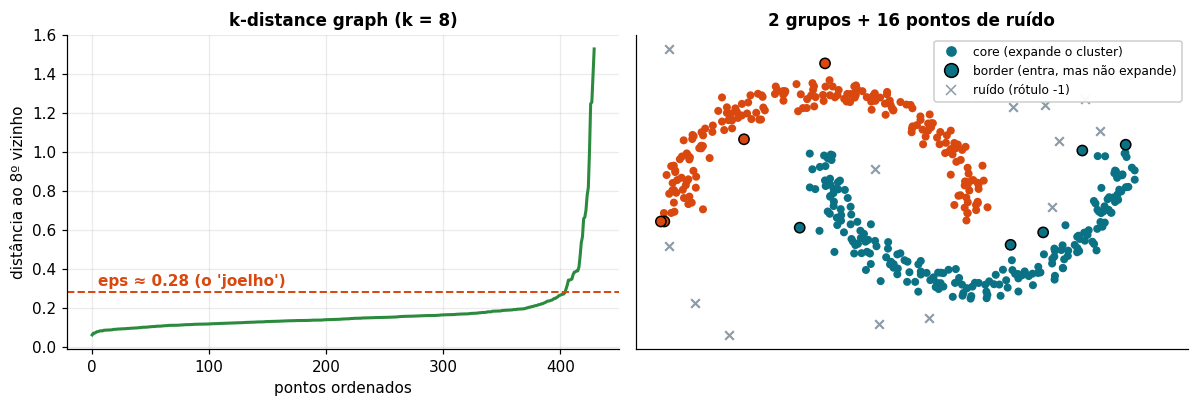

In [ ]:
# Dados com dois grupos curvos + 5% de ruído uniforme
Xm, _ = make_moons(n_samples=400, noise=0.06, random_state=SEED)
ruido = rng.uniform(Xm.min(0) - .3, Xm.max(0) + .3, size=(30, 2))
Xd = StandardScaler().fit_transform(np.vstack([Xm, ruido]))
MIN_PTS = 2 * Xd.shape[1] * 2   # regra de bolso: ~2 x dimensões (aqui reforçada por causa do ruído)
dist, _ = NearestNeighbors(n_neighbors=MIN_PTS).fit(Xd).kneighbors(Xd)
kdist = np.sort(dist[:, -1])

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

ax[0].plot(kdist, color=PALETA[3], lw=2)
ax[0].axhline(0.28, color=PALETA[1], ls="--", lw=1.3)
ax[0].text(5, 0.31, "eps ≈ 0.28 (o 'joelho')", color=PALETA[1], fontweight="bold")
ax[0].set_title(f"k-distance graph (k = {MIN_PTS})")
ax[0].set_xlabel("pontos ordenados")
ax[0].set_ylabel(f"distância ao {MIN_PTS}º vizinho")

db_ = DBSCAN(eps=0.28, min_samples=MIN_PTS).fit(Xd)
lab = db_.labels_
core = np.zeros(len(Xd), bool)
core[db_.core_sample_indices_] = True
border = (lab != -1) & ~core

from matplotlib.lines import Line2D

ax[1].scatter(*Xd[core].T,   c=cores(lab[core]),   s=18)
ax[1].scatter(*Xd[border].T, c=cores(lab[border]), s=45, edgecolor="black", linewidth=1.0)
ax[1].scatter(*Xd[lab == -1].T, c="#8C9BA8", s=32, marker="x", linewidth=1.4)
ax[1].legend(handles=[
    Line2D([], [], ls="", marker="o", color="#0B7285", label="core (expande o cluster)"),
    Line2D([], [], ls="", marker="o", color="#0B7285", markeredgecolor="black",
           markersize=9, label="border (entra, mas não expande)"),
    Line2D([], [], ls="", marker="x", color="#8C9BA8", label="ruído (rótulo -1)")
], loc="upper right", fontsize=8, framealpha=.95)
ax[1].set_title(f"{len(set(lab) - {-1})} grupos + {(lab == -1).sum()} pontos de ruído")
ax[1].set_xticks([])
ax[1].set_yticks([])

plt.tight_layout()
plt.show()

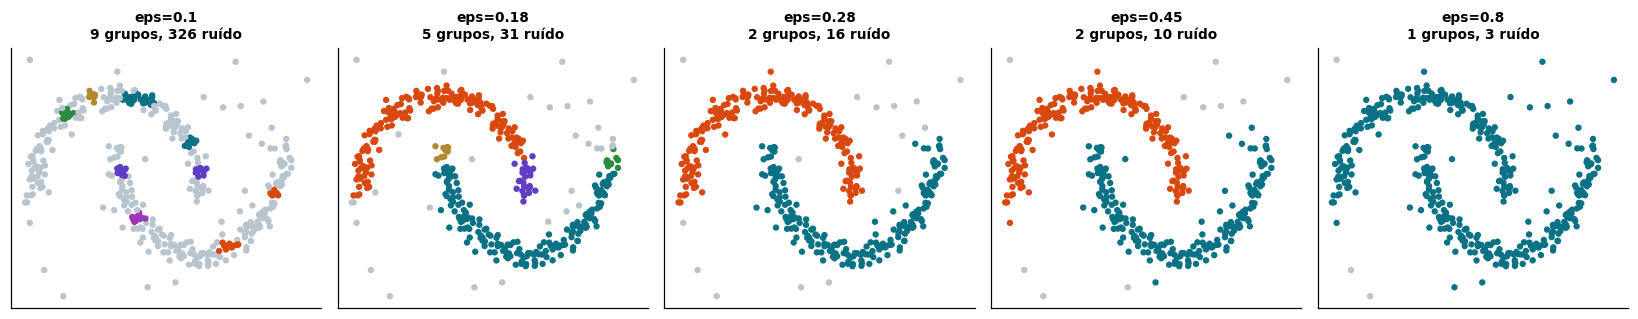

O eps é GLOBAL: um único valor precisa servir para todas as regiões do espaço.
Quando há densidades muito diferentes, nenhum eps único funciona — ver §10 (HDBSCAN).


In [67]:
fig, ax = plt.subplots(1, 5, figsize=(15, 3))
for a, eps in zip(ax, [0.10, 0.18, 0.28, 0.45, 0.80]):
    l = DBSCAN(eps=eps, min_samples=MIN_PTS).fit_predict(Xd)
    k = len(set(l) - {-1})
    a.scatter(*Xd.T, c=cores(l), s=10)
    a.set_title(f"eps={eps}\n{k} grupos, {(l==-1).sum()} ruído", fontsize=9)
    a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()
print("O eps é GLOBAL: um único valor precisa servir para todas as regiões do espaço.")
print("Quando há densidades muito diferentes, nenhum eps único funciona — ver §10 (HDBSCAN).")

---

## §6 — Três algoritmos em quatro geometrias

Nesta seção, o slide comparativo será transformado em um experimento prático. Aplicaremos **K-Means**, **clustering hierárquico** e **DBSCAN** a quatro conjuntos de dados com geometrias distintas.

Cada algoritmo incorpora uma hipótese diferente sobre o que caracteriza um grupo. Quando essa hipótese não corresponde à geometria dos dados, o algoritmo tende a falhar de maneira previsível.

> **Ideia central:** não existe um algoritmo de clustering universalmente superior. A escolha deve considerar o formato, a densidade, a separação e a presença de ruído nos dados.


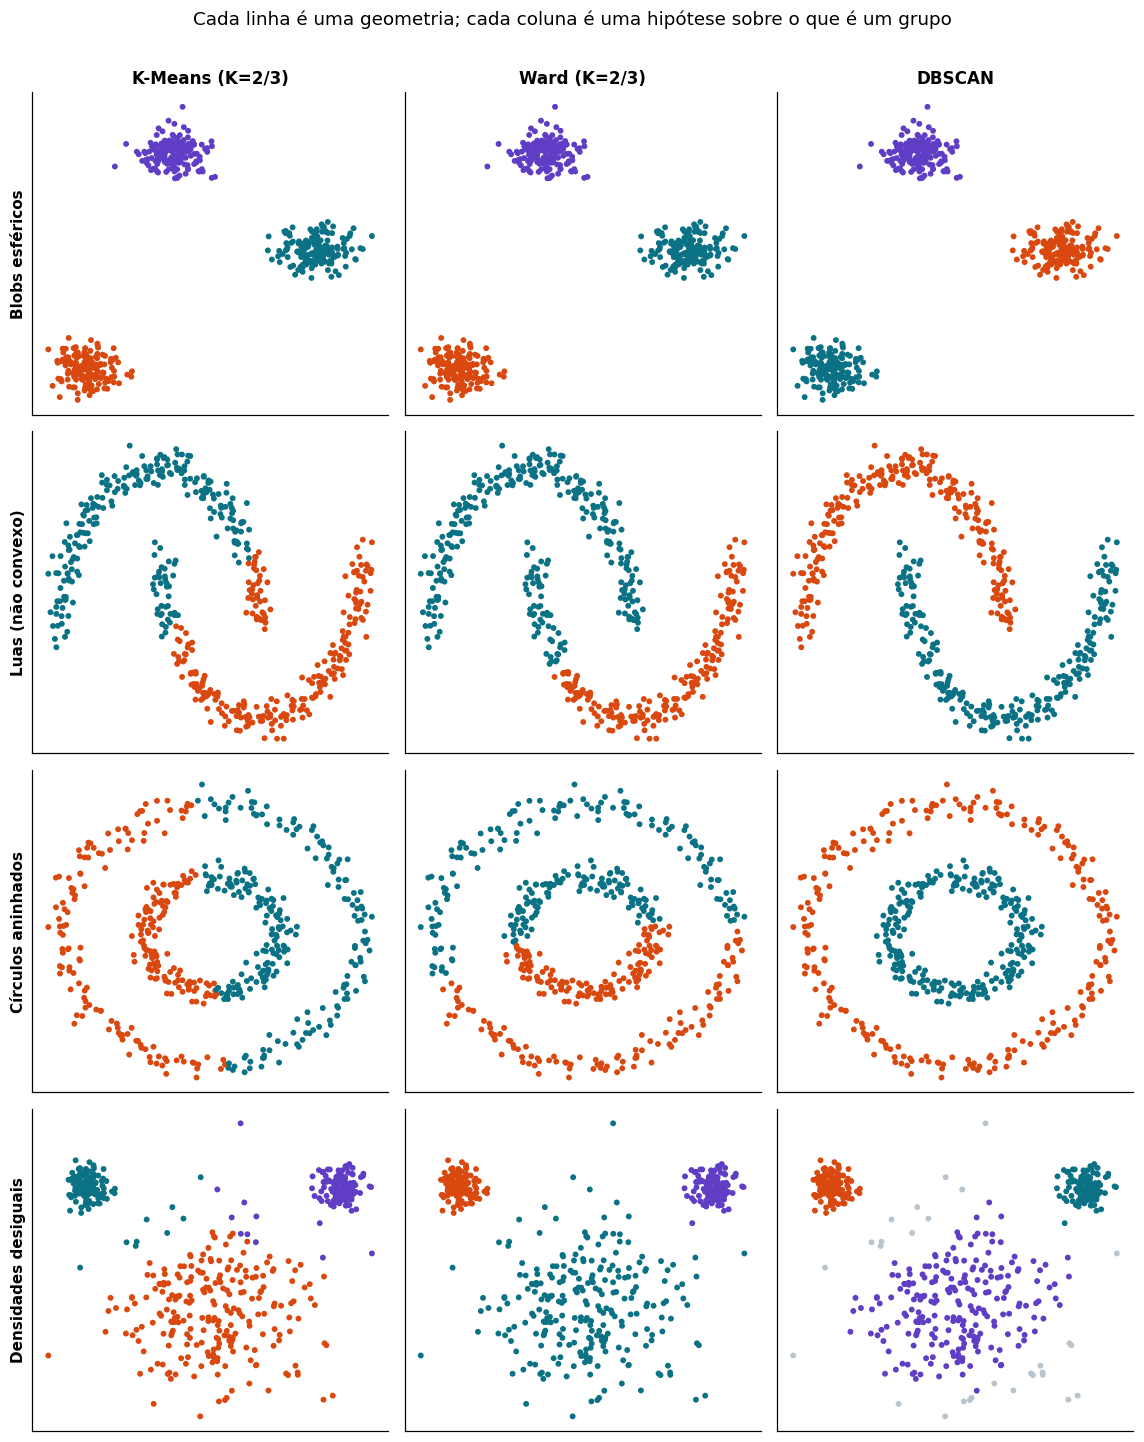

Leitura: K-Means e Ward acertam bolas e erram curvas; DBSCAN acerta curvas
e sofre quando as densidades são muito diferentes (última linha).


In [68]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

SEED = 42
PALETA = ["#0B7285", "#D9480F", "#5F3DC4", "#2B8A3E", "#B08A2E", "#9C36B5"]
def cores(labels):
    "Mapeia rótulos para cores; ruído (-1) fica cinza."
    return np.array(["#B8C4CE" if l == -1 else PALETA[int(l) % len(PALETA)] for l in labels])

def blobs_desiguais(n=500, seed=SEED):
    Xa, _ = make_blobs(n_samples=[n//2, n//4, n//4], centers=[[0,0],[4,4],[-4,4]],
                       cluster_std=[1.6, 0.35, 0.35], random_state=seed)
    return Xa

conjuntos = {
    "Blobs esféricos":     make_blobs(n_samples=500, centers=3, cluster_std=0.9, random_state=SEED)[0],
    "Luas (não convexo)":  make_moons(n_samples=500, noise=0.06, random_state=SEED)[0],
    "Círculos aninhados":  make_circles(n_samples=500, factor=0.45, noise=0.05, random_state=SEED)[0],
    "Densidades desiguais": blobs_desiguais(),
}
modelos = {
    "K-Means (K=2/3)":    lambda X, k: KMeans(k, n_init=10, random_state=SEED).fit_predict(X),
    "Ward (K=2/3)":       lambda X, k: AgglomerativeClustering(k, linkage="ward").fit_predict(X),
    "DBSCAN":             lambda X, k: DBSCAN(eps=0.30, min_samples=8).fit_predict(X),
}
fig, ax = plt.subplots(len(conjuntos), len(modelos), figsize=(10.5, 13))
for i, (nome, Xc) in enumerate(conjuntos.items()):
    Xc = StandardScaler().fit_transform(Xc)
    k = 2 if ("Luas" in nome or "Círculos" in nome) else 3
    for j, (mnome, f) in enumerate(modelos.items()):
        lab = f(Xc, k)
        a = ax[i, j]
        a.scatter(*Xc.T, c=cores(lab), s=8)
        a.set_xticks([]); a.set_yticks([])
        if i == 0: a.set_title(mnome, fontsize=11)
        if j == 0: a.set_ylabel(nome, fontsize=10, fontweight="bold")
plt.suptitle("Cada linha é uma geometria; cada coluna é uma hipótese sobre o que é um grupo", y=1.005)
plt.tight_layout(); plt.show()
print("Leitura: K-Means e Ward acertam bolas e erram curvas; DBSCAN acerta curvas")
print("e sofre quando as densidades são muito diferentes (última linha).")

---

## §7 — Avaliação: a média global pode esconder clusters ruins

A função `silhouette_score` retorna um único valor médio para avaliar a qualidade geral do agrupamento. Embora seja útil para comparar modelos, essa média pode ocultar clusters mal definidos ou observações classificadas de forma inadequada.

O **gráfico de silhueta** (*silhouette plot*) apresenta os coeficientes de cada observação, organizados por cluster, permitindo um diagnóstico mais detalhado.

Com ele, é possível identificar:

* clusters bem separados, com valores de silhueta elevados;
* clusters pouco coesos ou sobrepostos;
* diferenças significativas de tamanho entre os grupos;
* observações próximas das fronteiras;
* valores negativos, que podem indicar atribuições inadequadas.

> **Ideia central:** o `silhouette_score` resume o desempenho, enquanto o **gráfico de silhueta** mostra onde e por que o agrupamento pode estar falhando.


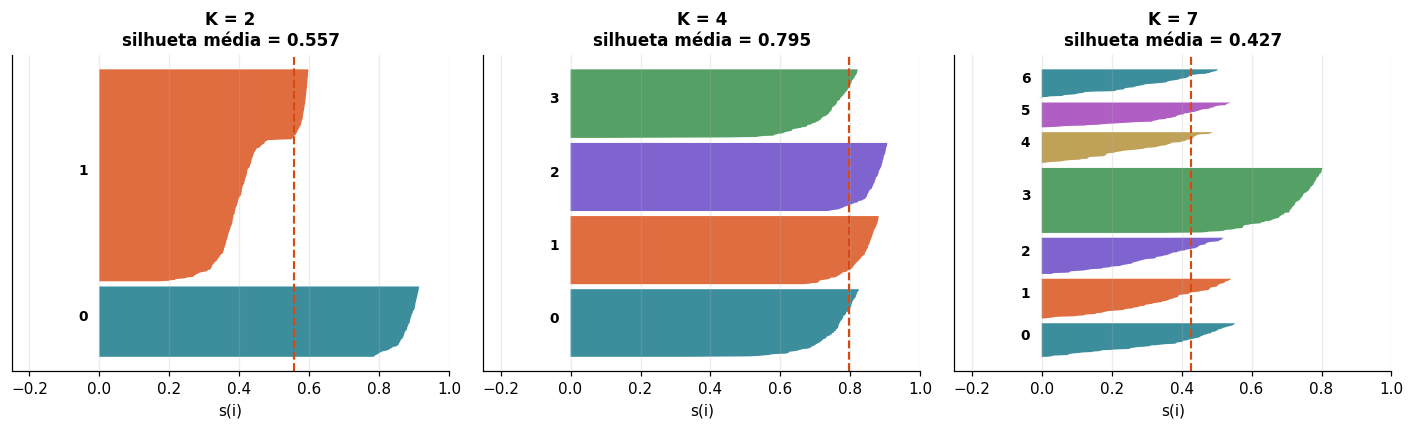

Com K=7, a média ainda parece aceitável — mas há clusters inteiros com silhueta baixa.
Um cluster inteiro com s baixo é um cluster que não deveria existir.


In [69]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples

SEED = 42
PALETA = ["#0B7285", "#D9480F", "#5F3DC4", "#2B8A3E", "#B08A2E", "#9C36B5"]
def cores(labels):
    "Mapeia rótulos para cores; ruído (-1) fica cinza."
    return np.array(["#B8C4CE" if l == -1 else PALETA[int(l) % len(PALETA)] for l in labels])

def silhouette_plot(X, labels, ax, titulo=""):
    mask = labels != -1
    X, labels = X[mask], labels[mask]
    vals = silhouette_samples(X, labels)
    media = vals.mean()
    y = 10
    for j in np.unique(labels):
        v = np.sort(vals[labels == j])
        ax.fill_betweenx(np.arange(y, y + len(v)), 0, v,
                         facecolor=PALETA[j % len(PALETA)], alpha=.8)
        ax.text(-0.06, y + len(v) / 2, str(j), fontsize=9, fontweight="bold")
        y += len(v) + 10
    ax.axvline(media, color=PALETA[1], ls="--", lw=1.4)
    ax.set_title(f"{titulo}\nsilhueta média = {media:.3f}")
    ax.set_xlabel("s(i)"); ax.set_yticks([]); ax.set_xlim(-0.25, 1)
    return media

Xg = StandardScaler().fit_transform(make_blobs(n_samples=600, centers=4,
                                               cluster_std=1.0, random_state=SEED)[0])
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
for a, k in zip(ax, [2, 4, 7]):
    silhouette_plot(Xg, KMeans(k, n_init=10, random_state=SEED).fit_predict(Xg), a, f"K = {k}")
plt.tight_layout(); plt.show()
print("Com K=7, a média ainda parece aceitável — mas há clusters inteiros com silhueta baixa.")
print("Um cluster inteiro com s baixo é um cluster que não deveria existir.")

In [71]:
# Métricas internas vs externa (ARI) quando conhecemos a verdade
Xv, yv = make_blobs(n_samples=600, centers=4, cluster_std=1.0, random_state=SEED)
Xv = StandardScaler().fit_transform(Xv)
linhas = []
for nome, lab in {
    "K-Means K=4":  KMeans(4, n_init=10, random_state=SEED).fit_predict(Xv),
    "K-Means K=6":  KMeans(6, n_init=10, random_state=SEED).fit_predict(Xv),
    "Ward K=4":     AgglomerativeClustering(4, linkage="ward").fit_predict(Xv),
    "DBSCAN":       DBSCAN(eps=0.35, min_samples=8).fit_predict(Xv),
}.items():
    m = lab != -1
    linhas.append({
        "modelo": nome,
        "n_clusters": len(set(lab[m])),
        "ruído": int((lab == -1).sum()),
        "silhueta": round(silhouette_score(Xv[m], lab[m]), 3),
        "davies_bouldin": round(davies_bouldin_score(Xv[m], lab[m]), 3),
        "calinski_h": round(calinski_harabasz_score(Xv[m], lab[m]), 1),
        "ARI (vs verdade)": round(adjusted_rand_score(yv, lab), 3),
    })
display(pd.DataFrame(linhas).set_index("modelo"))
print("Cuidado: a silhueta favorece formatos convexos — ela é injusta com o DBSCAN")
print("em dados de formato arbitrário. Nunca use uma métrica só.")

,n_clusters,ruído,silhueta,davies_bouldin,calinski_h,ARI (vs verdade)
modelo,,,,,,
K-Means K=4,4,0,0.795,0.288,6441.1,0.996
K-Means K=6,6,0,0.563,0.849,4776.4,0.817
Ward K=4,4,0,0.795,0.288,6441.1,0.996
DBSCAN,3,0,0.742,0.370,2185.3,0.713


Cuidado: a silhueta favorece formatos convexos — ela é injusta com o DBSCAN
em dados de formato arbitrário. Nunca use uma métrica só.


---

## §8 — A principal armadilha: o algoritmo sempre encontra clusters

Algoritmos de clustering podem produzir agrupamentos mesmo quando os dados não apresentam nenhuma estrutura natural. Portanto, a simples existência de clusters no resultado não comprova que eles sejam reais, estáveis ou relevantes.

Antes de interpretar ou nomear qualquer segmentação, é necessário verificar se há uma estrutura de agrupamento efetivamente presente nos dados.

Essa análise pode incluir:

* inspeção visual da distribuição dos dados;
* comparação com dados aleatórios ou modelos nulos;
* análise de tendência de agrupamento, como a estatística de Hopkins;
* avaliação da estabilidade dos clusters;
* validação por diferentes métricas e algoritmos;
* análise da interpretabilidade e da utilidade prática dos grupos.

> **Ideia central:** encontrar clusters é fácil; demonstrar que eles representam uma estrutura verdadeira e útil é a parte mais importante da análise.


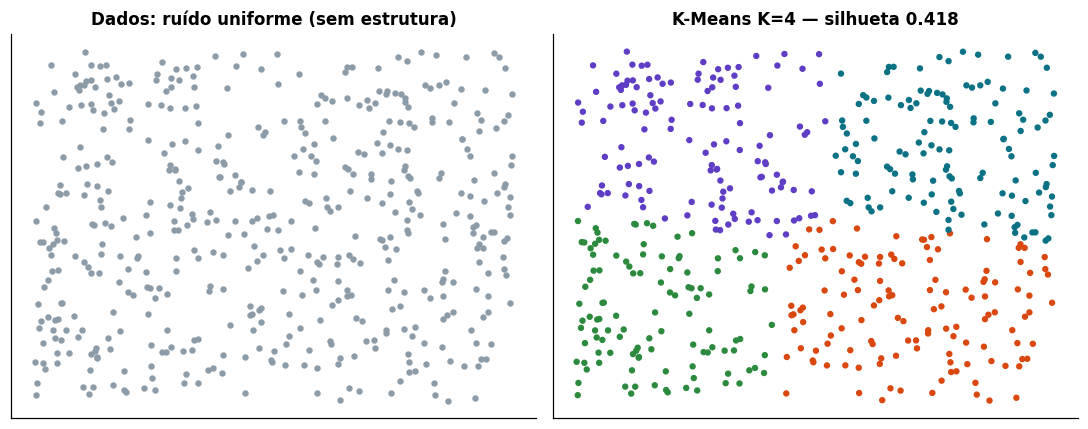

O algoritmo produziu quatro 'segmentos' convincentes a partir de nada.


In [73]:
# Ruído uniforme puro: nenhuma estrutura existe aqui
X_ruido = rng.uniform(0, 1, size=(500, 2))
lab_ruido = KMeans(4, n_init=10, random_state=SEED).fit_predict(X_ruido)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(*X_ruido.T, c="#8C9BA8", s=10)
ax[0].set_title("Dados: ruído uniforme (sem estrutura)")
ax[1].scatter(*X_ruido.T, c=cores(lab_ruido), s=10)
ax[1].set_title(f"K-Means K=4 — silhueta {silhouette_score(X_ruido, lab_ruido):.3f}")
for a in ax:
    a.set_xticks([])
    a.set_yticks([])
plt.tight_layout()
plt.show()
print("O algoritmo produziu quatro 'segmentos' convincentes a partir de nada.")

In [75]:
# Estatística de Hopkins: mede a tendência de agrupamento (≈0.5 sem estrutura, →1 com estrutura)
def hopkins(X, frac=0.1, seed=SEED):
    r = np.random.default_rng(seed)
    n, d = X.shape
    m = max(int(frac * n), 5)
    amostra = X[r.choice(n, m, replace=False)]
    aleatorios = r.uniform(X.min(0), X.max(0), size=(m, d))
    nn = NearestNeighbors(n_neighbors=2).fit(X)
    u = nn.kneighbors(aleatorios, n_neighbors=1)[0].ravel()   # do ponto aleatório ao dado mais próximo
    w = nn.kneighbors(amostra,   n_neighbors=2)[0][:, 1]      # do dado ao vizinho real mais próximo
    return u.sum() / (u.sum() + w.sum())
X_estrut = StandardScaler().fit_transform(
    make_blobs(n_samples=500, centers=4, cluster_std=0.8, random_state=SEED)[0])
print(f"Hopkins — ruído uniforme      : {hopkins(X_ruido):.3f}  (≈0.5 → não há o que agrupar)")
print(f"Hopkins — dados com 4 grupos  : {hopkins(X_estrut):.3f}  (perto de 1 → há estrutura)")
print("\nRode este teste ANTES de apresentar qualquer segmentação.")

Hopkins — ruído uniforme      : 0.137  (≈0.5 → não há o que agrupar)
Hopkins — dados com 4 grupos  : 0.942  (perto de 1 → há estrutura)

Rode este teste ANTES de apresentar qualquer segmentação.


In [77]:
# Maldição da dimensionalidade: em muitas dimensões, 'perto' perde significado
print(f"{'dimensões':>10} {'d_min/d_max':>13} {'contraste':>11}")
for d in [2, 5, 20, 100, 500]:
    P = rng.normal(size=(300, d))
    D = np.sqrt(((P[:, None, :] - P[None, :, :]) ** 2).sum(-1))
    D = D[~np.eye(len(P), dtype=bool)]
    print(f"{d:>10} {D.min()/D.max():>13.3f} {(D.max()-D.min())/D.mean():>11.3f}")
print("\nO contraste entre a menor e a maior distância desaba: todos ficam 'igualmente longe'.")
print("Solução prática: reduzir dimensionalidade (PCA/UMAP) antes de agrupar.")

 dimensões   d_min/d_max   contraste
         2         0.002       3.159
         5         0.037       2.374
        20         0.260       1.313
       100         0.560       0.557
       500         0.750       0.281

O contraste entre a menor e a maior distância desaba: todos ficam 'igualmente longe'.
Solução prática: reduzir dimensionalidade (PCA/UMAP) antes de agrupar.


---

## §9 — Caso aplicado: segmentação RFM de ponta a ponta

A análise **RFM** segmenta clientes com base em três dimensões do comportamento de compra:

* **R — *Recency* (recência):** quantidade de dias desde a última compra;
* **F — *Frequency* (frequência):** número de compras realizadas;
* **M — *Monetary* (valor monetário):** valor total gasto pelo cliente.

Nesta seção, utilizaremos transações sintéticas para construir todo o processo de segmentação. Embora os dados sejam simulados, o pipeline reproduz as principais etapas de um projeto real:

1. geração e organização das transações;
2. cálculo das variáveis RFM por cliente;
3. tratamento das distribuições e valores extremos;
4. transformação e padronização das variáveis;
5. escolha do número de clusters;
6. aplicação do algoritmo de agrupamento;
7. caracterização e interpretação dos segmentos;
8. tradução dos resultados em possíveis ações de negócio.

> **Ideia central:** o algoritmo encontra grupos matematicamente semelhantes, mas cabe ao analista transformar esses agrupamentos em segmentos compreensíveis e úteis para a tomada de decisão.


In [79]:
# 1) Gerar transações sintéticas (substitua por seu CSV real quando aplicar)
n_clientes = 1200
perfil = rng.choice(["campeao", "fiel", "risco", "perdido"], n_clientes, p=[.15, .35, .3, .2])
param = {"campeao": (12, 22, 320), "fiel": (45, 10, 180), "risco": (150, 4, 120), "perdido": (300, 2, 60)}
reg = []
for i, p in enumerate(perfil):
    r_, f_, m_ = param[p]
    reg.append({
        "CustomerID": f"C{i:05d}",
        "Recency":   max(1, rng.normal(r_, r_ * 0.30)),
        "Frequency": max(1, rng.normal(f_, f_ * 0.30)),
        "TicketMedio": max(10, rng.normal(m_, m_ * 0.35)),
        "perfil_real": p,
    })
rfm = pd.DataFrame(reg)
rfm["Monetary"] = rfm.Frequency * rfm.TicketMedio
print(rfm.head(3).round(1).to_string(index=False))
print("\nAssimetria antes do log:")
print(rfm[["Recency", "Frequency", "Monetary"]].skew().round(2).to_string())

CustomerID  Recency  Frequency  TicketMedio perfil_real  Monetary
    C00000     61.8        4.3         68.5       risco     293.0
    C00001    113.2        3.6         39.8       risco     144.5
    C00002     26.3       12.4        140.1        fiel    1737.5

Assimetria antes do log:
Recency      1.28
Frequency    1.49
Monetary     2.57


Assimetria depois do log1p:
Recency     -0.26
Frequency    0.28
Monetary    -0.04


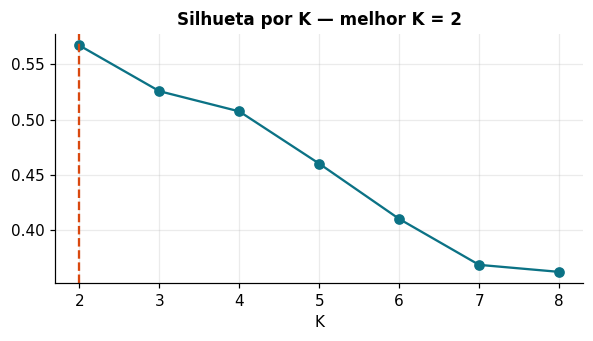

In [81]:
feat = ["Recency", "Frequency", "Monetary"]
X_rfm = np.log1p(rfm[feat].values)
scaler = StandardScaler().fit(X_rfm)          # guarde este scaler junto do modelo!
Z_rfm = scaler.transform(X_rfm)
print("Assimetria depois do log1p:")
print(pd.DataFrame(X_rfm, columns=feat).skew().round(2).to_string())

# 3) Escolher K
ks = range(2, 9)
s_ = [silhouette_score(Z_rfm, KMeans(k, n_init=10, random_state=SEED).fit_predict(Z_rfm)) for k in ks]
plt.figure(figsize=(5.5, 3.2))
plt.plot(list(ks), s_, "o-", color=PALETA[0])
plt.axvline(list(ks)[int(np.argmax(s_))], color=PALETA[1], ls="--")
plt.title(f"Silhueta por K — melhor K = {list(ks)[int(np.argmax(s_))]}"); plt.xlabel("K")
plt.tight_layout(); plt.show()

silhueta        : 0.507
davies-bouldin  : 0.671
ARI vs perfil real: 0.798  (só existe porque os dados são sintéticos)


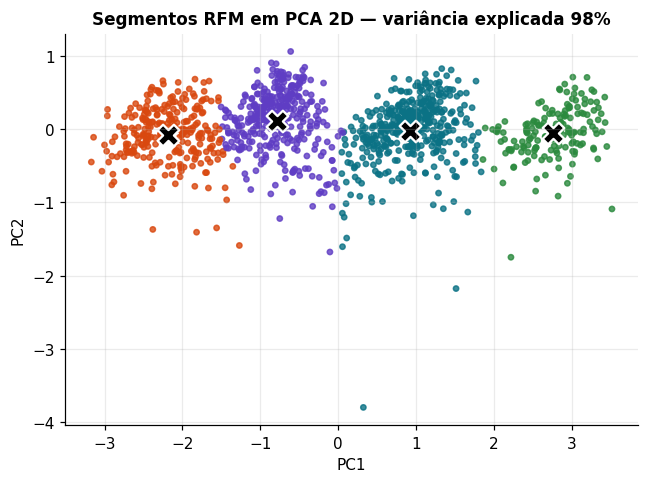

In [83]:
# 4) Agrupar e 5) avaliar
K = 4
km = KMeans(K, n_init=20, random_state=SEED).fit(Z_rfm)
rfm["cluster"] = km.labels_
print(f"silhueta        : {silhouette_score(Z_rfm, km.labels_):.3f}")
print(f"davies-bouldin  : {davies_bouldin_score(Z_rfm, km.labels_):.3f}")
print(f"ARI vs perfil real: {adjusted_rand_score(rfm.perfil_real, km.labels_):.3f}" \
      "  (só existe porque os dados são sintéticos)")

# 6) Visualizar em 2D via PCA
pca = PCA(2).fit(Z_rfm)
P = pca.transform(Z_rfm)
plt.figure(figsize=(6, 4.5))
plt.scatter(*P.T, c=cores(km.labels_), s=12, alpha=.8)
plt.scatter(*pca.transform(km.cluster_centers_).T, c="black", s=200, marker="X", \
            edgecolor="white", linewidth=1.5)
plt.title(f"Segmentos RFM em PCA 2D — variância explicada " \
          f"{pca.explained_variance_ratio_.sum():.0%}")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout(); plt.show()

,segmento,clientes,% da base,% da receita,recency_mediana,frequency_mediana,monetary_mediano,ação sugerida
cluster,,,,,,,,
0,Fiéis,409,34.1,33.3,43.4,10.1,1687.9,cross-sell e aumento de ticket
1,Perdidos,264,22.0,1.5,286.1,2.0,118.2,campanha de winback de baixo custo ou descarte
2,Em risco,355,29.6,8.4,145.7,4.3,490.1,cupom de reativação com prazo curto
3,Campeões,172,14.3,56.8,12.4,22.6,6815.9,programa de indicação + acesso antecipado


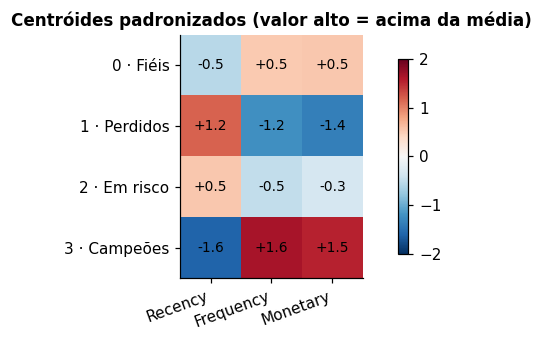

In [85]:
# 7) Traduzir: perfil, tamanho, receita e ação — o passo que paga a conta
perfil_tab = rfm.groupby("cluster").agg(
    clientes=("CustomerID", "count"),
    recency_mediana=("Recency", "median"),
    frequency_mediana=("Frequency", "median"),
    monetary_mediano=("Monetary", "median"),
    receita_total=("Monetary", "sum"),
).round(1)

perfil_tab["% da base"] = (perfil_tab.clientes / len(rfm) * 100).round(1)
perfil_tab["% da receita"] = (perfil_tab.receita_total / rfm.Monetary.sum() * 100).round(1)

# Nomeação automática por regra simples (em projeto real, nomeie junto com a área de negócio)
def nomear(r):
    if r.recency_mediana < 40 and r.monetary_mediano > perfil_tab.monetary_mediano.median():
        return "Campeões"
    if r.recency_mediana < 90:
        return "Fiéis"
    if r.recency_mediana < 220:
        return "Em risco"
    return "Perdidos"

perfil_tab["segmento"] = perfil_tab.apply(nomear, axis=1)
acões = {"Campeões": "programa de indicação + acesso antecipado",
         "Fiéis": "cross-sell e aumento de ticket",
         "Em risco": "cupom de reativação com prazo curto",
         "Perdidos": "campanha de winback de baixo custo ou descarte"}
perfil_tab["ação sugerida"] = perfil_tab.segmento.map(acões)
display(perfil_tab[["segmento", "clientes", "% da base", "% da receita",
                    "recency_mediana", "frequency_mediana", "monetary_mediano", "ação sugerida"]])

# Perfil médio padronizado por cluster (heatmap simples, sem seaborn)
centros = pd.DataFrame(km.cluster_centers_, columns=[f"log_{c}" for c in feat])
fig, ax = plt.subplots(figsize=(6.8, 3.2))
im = ax.imshow(centros.values, cmap="RdBu_r", vmin=-2, vmax=2)
ax.set_xticks(range(3), feat, rotation=20, ha="right")
ax.set_yticks(range(K), [f"{i} · {perfil_tab.segmento[i]}" for i in range(K)])
for i in range(K):
    for j in range(3):
        ax.text(j, i, f"{centros.values[i, j]:+.1f}", ha="center", va="center", fontsize=9)
ax.set_title("Centróides padronizados (valor alto = acima da média)")
plt.colorbar(im, shrink=.8); ax.grid(False)
plt.tight_layout(); plt.show()

---

## §10 — Estado da arte executável

Nesta seção, serão apresentadas duas demonstrações práticas, executáveis diretamente no Google Colab e sem instalações adicionais, que ilustram avanços recentes na análise de agrupamentos:

1. **HDBSCAN:** extensão hierárquica do DBSCAN capaz de identificar clusters com diferentes densidades, estimar a estabilidade dos grupos e classificar automaticamente pontos como ruído.
2. **Clustering de textos:** utilização de representações vetoriais para agrupar documentos semanticamente semelhantes, indo além da simples contagem de palavras.

Esses exemplos mostram duas direções importantes da área:

* modelos mais robustos para dados com densidades variáveis e presença de ruído;
* agrupamento de dados complexos e não estruturados, como textos representados por vetores de alta dimensionalidade.

> **Ideia central:** o clustering contemporâneo combina algoritmos baseados em densidade, representações vetoriais e critérios de estabilidade para encontrar estruturas mais flexíveis e semanticamente relevantes.


### 10.1 — HDBSCAN: densidade sem `eps` globalO `sklearn.cluster.HDBSCAN` (disponível desde a versão 1.3) varre todas as escalas de densidade eextrai os clusters mais estáveis. É a resposta direta à limitação que vimos em §5.

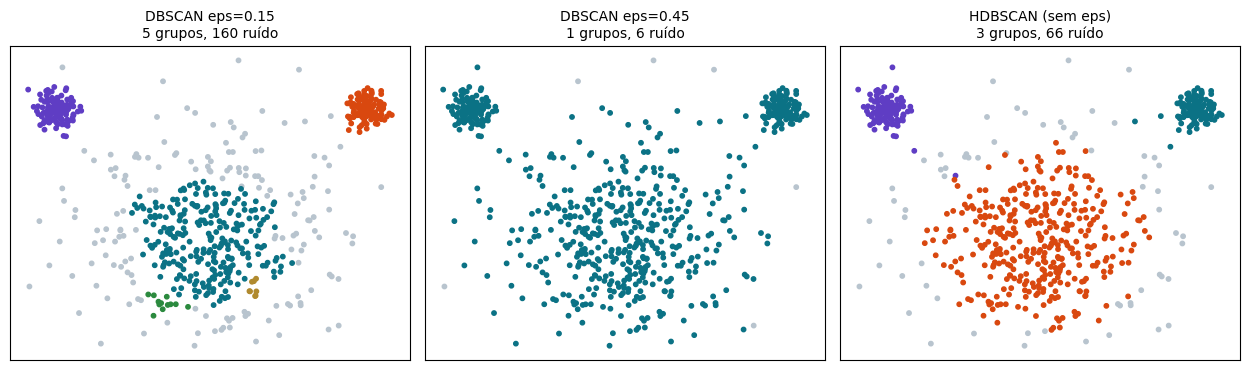

eps pequeno: os blobs apertados sobrevivem, mas o blob largo vira quase todo ruído.
eps grande : o blob largo é recuperado, porém os pontos de ruído espalhados servem
             de PONTE e fundem grupos que estavam separados.
Nenhum eps único serve para as duas densidades — o HDBSCAN não precisa escolher um.


In [ ]:
from sklearn.datasets import make_blobs
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

PALETA = ["#0B7285", "#D9480F", "#5F3DC4", "#2B8A3E", "#B08A2E", "#9C36B5"]
def cores(labels):
    "Mapeia rótulos para cores; ruído (-1) fica cinza."
    return np.array(["#B8C4CE" if l == -1 else PALETA[int(l) % len(PALETA)] for l in labels])

SEED = 42
rng = np.random.default_rng(SEED)
try:
    from sklearn.cluster import HDBSCAN
    tem_hdbscan = True
except ImportError:
    tem_hdbscan = False
    print("Sua versão do scikit-learn não traz HDBSCAN (precisa ser >= 1.3).")
# Dados com densidades bem diferentes: um blob largo e dois blobs apertados
Xh, _ = make_blobs(n_samples=[400, 120, 120], centers=[[0, 0], [5, 5], [-5, 5]],
                   cluster_std=[1.8, 0.35, 0.35], random_state=SEED)
Xh = np.vstack([Xh, rng.uniform(Xh.min(0), Xh.max(0), size=(40, 2))])   # + ruído
Xh = StandardScaler().fit_transform(Xh)
resultados = {"DBSCAN eps=0.15": DBSCAN(eps=0.15, min_samples=8).fit_predict(Xh),
              "DBSCAN eps=0.45": DBSCAN(eps=0.45, min_samples=8).fit_predict(Xh)}
if tem_hdbscan:
    resultados["HDBSCAN (sem eps)"] = HDBSCAN(min_cluster_size=25).fit_predict(Xh)
fig, ax = plt.subplots(1, len(resultados), figsize=(4.2 * len(resultados), 3.8))
for a, (nome, lab) in zip(np.atleast_1d(ax), resultados.items()):
    a.scatter(*Xh.T, c=cores(lab), s=10)
    a.set_title(f"{nome}\n{len(set(lab) - {-1})} grupos, {(lab == -1).sum()} ruído", fontsize=10)
    a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()
print("eps pequeno: os blobs apertados sobrevivem, mas o blob largo vira quase todo ruído.")
print("eps grande : o blob largo é recuperado, porém os pontos de ruído espalhados servem")
print("             de PONTE e fundem grupos que estavam separados.")
print("Nenhum eps único serve para as duas densidades — o HDBSCAN não precisa escolher um.")

### 10.2 — Clustering de textos: o pipeline do BERTopic em versão offline

O pipeline moderno de clustering de textos segue quatro etapas principais:

`representação vetorial → redução de dimensionalidade → clustering por densidade → nomeação dos tópicos`

Nesta demonstração, utilizaremos **TF-IDF** no lugar dos *embeddings* produzidos por um modelo de linguagem. Essa escolha permite executar o exemplo completamente offline, sem baixar modelos e sem utilizar chaves de API.

Embora a representação vetorial seja mais simples, a estrutura geral do pipeline permanece a mesma utilizada pelo **BERTopic**:

1. **Representação vetorial:** transforma os textos em vetores TF-IDF;
2. **Redução de dimensionalidade:** projeta os vetores em um espaço mais compacto;
3. **Clustering por densidade:** identifica grupos de textos semelhantes e possíveis documentos classificados como ruído;
4. **Nomeação dos tópicos:** utiliza os termos mais representativos de cada grupo para interpretar e nomear os temas encontrados.

Para comparar os textos, utilizaremos a **similaridade de cosseno**, mais adequada para vetores textuais esparsos do que a distância euclidiana.

> **Ideia central:** o TF-IDF substitui os *embeddings* nesta demonstração, mas preserva a lógica do pipeline moderno de descoberta de tópicos adotada pelo BERTopic.


Tópico 0  ->  time, torcida, campeonato, gol, jogo
     · o time marcou o gol decisivo e a torcida comemorou o campeonato
     · o campeonato de futebol teve tres gols e a torcida lotou o estadio

Tópico 1  ->  modelo, dados, rede, neural, treinado
     · o modelo de linguagem foi treinado com dados e ajusta seus parametros
     · a rede neural do modelo aprende representacoes a partir dos dados

Tópico 2  ->  receita, forno, panela, massa, tempero
     · a receita leva massa fresca e vai ao forno em fogo baixo
     · tempere a carne e leve ao forno seguindo a receita da panela



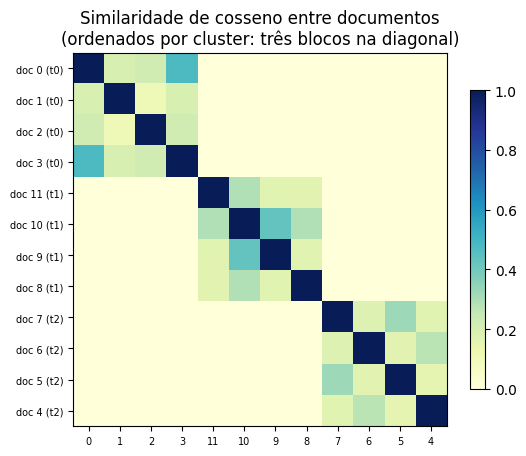

Dimensão original (TF-IDF): 59 termos  ->  após SVD/LSA: 5 componentes

Troque TF-IDF por sentence-transformers, SVD por UMAP e o linkage por HDBSCAN:
isso é, literalmente, o BERTopic.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD

STOPWORDS = ("a o e de do da em no na os as um uma para com que por ao aos se seu sua " \
             "dos das nao mais foi ser tem ate bem").split()
corpus = [
    # futebol
    "o time marcou o gol decisivo e a torcida comemorou o campeonato",
    "o campeonato de futebol teve tres gols e a torcida lotou o estadio",
    "o tecnico escalou o time e o atacante marcou dois gols no jogo",
    "a torcida do time acompanhou o jogo do campeonato ate o ultimo gol",
    # culinaria
    "a receita leva massa fresca e vai ao forno em fogo baixo",
    "tempere a carne e leve ao forno seguindo a receita da panela",
    "a massa da receita descansa antes de ir ao forno bem quente",
    "coloque o tempero na panela e finalize a receita no forno",
    # IA
    "o modelo de linguagem foi treinado com dados e ajusta seus parametros",
    "a rede neural do modelo aprende representacoes a partir dos dados",
    "o algoritmo agrupa os dados usando o modelo de rede neural treinado",
    "o treinamento do modelo usa dados vetoriais e um algoritmo de otimizacao",
]

# 1) "EMBEDDINGS" — aqui TF-IDF; em produção, sentence-transformers
vec = TfidfVectorizer(stop_words=STOPWORDS)
E = vec.fit_transform(corpus)
vocab = np.array(vec.get_feature_names_out())

# 2) REDUÇÃO DE DIMENSIONALIDADE — aqui SVD/LSA; em produção, UMAP
E_red = TruncatedSVD(n_components=5, random_state=SEED).fit_transform(E)

# 3) CLUSTERING com métrica de cosseno (1 - similaridade), não euclidiana
D = 1 - cosine_similarity(E)
lab_txt = AgglomerativeClustering(n_clusters=3, metric="precomputed",
                                  linkage="average").fit_predict(D)

# 4) NOMEAÇÃO DO TÓPICO — termos mais distintivos de cada grupo (a ideia do c-TF-IDF)
A = E.toarray()
for c in np.unique(lab_txt):
    distintividade = A[lab_txt == c].mean(0) - A[lab_txt != c].mean(0)
    termos = vocab[np.argsort(distintividade)[-5:]][::-1]
    print(f"Tópico {c}  ->  {', '.join(termos)}")
    for t in np.array(corpus)[lab_txt == c][:2]:
        print(f"     · {t}")
    print()

# A estrutura de blocos na matriz de similaridade é o que o clustering encontra
ordem = np.argsort(lab_txt)
S = cosine_similarity(E)[np.ix_(ordem, ordem)]

fig, ax = plt.subplots(figsize=(5.6, 4.6))
im = ax.imshow(S, cmap="YlGnBu", vmin=0, vmax=1)
ax.set_xticks(range(len(corpus)), ordem, fontsize=7)
ax.set_yticks(range(len(corpus)), [f"doc {i} (t{lab_txt[i]})" for i in ordem], fontsize=7)
ax.set_title("Similaridade de cosseno entre documentos\n(ordenados por cluster: três blocos na diagonal)")
plt.colorbar(im, shrink=.8); ax.grid(False)
plt.tight_layout(); plt.show()

print(f"Dimensão original (TF-IDF): {E.shape[1]} termos  ->  após SVD/LSA: {E_red.shape[1]} componentes\n")
print("Troque TF-IDF por sentence-transformers, SVD por UMAP e o linkage por HDBSCAN:")
print("isso é, literalmente, o BERTopic.")

---

## Para levar

1. **Clustering responde à pergunta “que estrutura existe aqui?”** — e a resposta depende inteiramente de como foi definido o conceito de *similaridade*.

2. **Escalar as variáveis não é apenas uma etapa de preparação: é parte do modelo.**

3. **Cada algoritmo representa uma hipótese geométrica:**

   * **K-Means:** grupos aproximadamente esféricos;
   * **Clustering hierárquico:** uma estrutura de árvore;
   * **DBSCAN:** regiões de alta densidade separadas por regiões de baixa densidade.

4. **Não existe um valor de K matematicamente correto** — existe um valor defensável, estável sob reamostragem, interpretável e útil para a tomada de decisão.

5. **O algoritmo pode encontrar grupos até mesmo em dados formados por ruído puro**, como demonstrado na §8. Cabe ao analista produzir evidências de que esses grupos representam uma estrutura real e relevante.

### Exercícios sugeridos

* Na §9, substitua `KMeans` por `AgglomerativeClustering(linkage="ward")` e compare os perfis dos segmentos. As conclusões de negócio mudam?

* Na §9, remova a transformação `log1p` e observe o efeito sobre a distribuição e o tamanho dos clusters.

* Na §5, altere `min_samples` mantendo `eps` fixo. Observe como a quantidade de clusters e de pontos classificados como ruído se modifica. Qual dos parâmetros parece mais sensível?

* Na §8, aplique o teste de Hopkins aos seus próprios dados antes de realizar a próxima segmentação.
